# Categorização de corredores — KMeans

Clusterização de atletas com base em distância mediana, pace mediano e frequência semanal (derivada do timestamp).

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from dataset.analise import carregar_dataset
from dataset.categorizar.definir_perfil_atleta import definir_perfil_atleta
from dataset.categorizar.kmeans import treina_kmeans
from dataset.categorizar.visualizacao_fichas import (
    montar_fichas_atletas,
    plotar_ficha_atleta,
    plotar_fichas_atletas,
    tabela_fichas,
)
from dataset.constants import (
    COL_ATHLETE,
    COL_CLUSTER_CORREDOR,
    COL_DISTANCE,
    COL_FREQUENCIA,
    COL_GENDER,
    COL_NIVEL_DISTANCIA,
    COL_NIVEL_PACE,
    COL_NIVEL_VOLUME,
    COL_PACE,
    COL_PERFIL_ATLETA,
)
from dataset.normalizacao import normalizar

In [2]:
df_raw = carregar_dataset(root / "dataset/raw-data-kaggle.csv")
df = normalizar(df_raw)

print(f"Corridas: {df.height} | Atletas: {df[COL_ATHLETE].n_unique()}")

Corridas: 40534 | Atletas: 114


## Treinar KMeans

Cada atleta é representado por:
- **distância mediana** (`COL_DISTANCE`)
- **pace mediano** (`COL_PACE`)
- **frequência semanal** (derivada de `COL_TIMESTAMP`)

Inércia: 176.4359
Silhouette: 0.3621
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 12      │
│ 1                ┆ 24      │
│ 2                ┆ 78      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: dist=10.83 km | pace=5.19 min/km | freq=4.45 corridas/semana
  cluster_1: dist=6.59 km | pace=6.26 min/km | freq=1.10 corridas/semana
  cluster_2: dist=10.39 km | pace=5.69 min/km | freq=1.94 corridas/semana


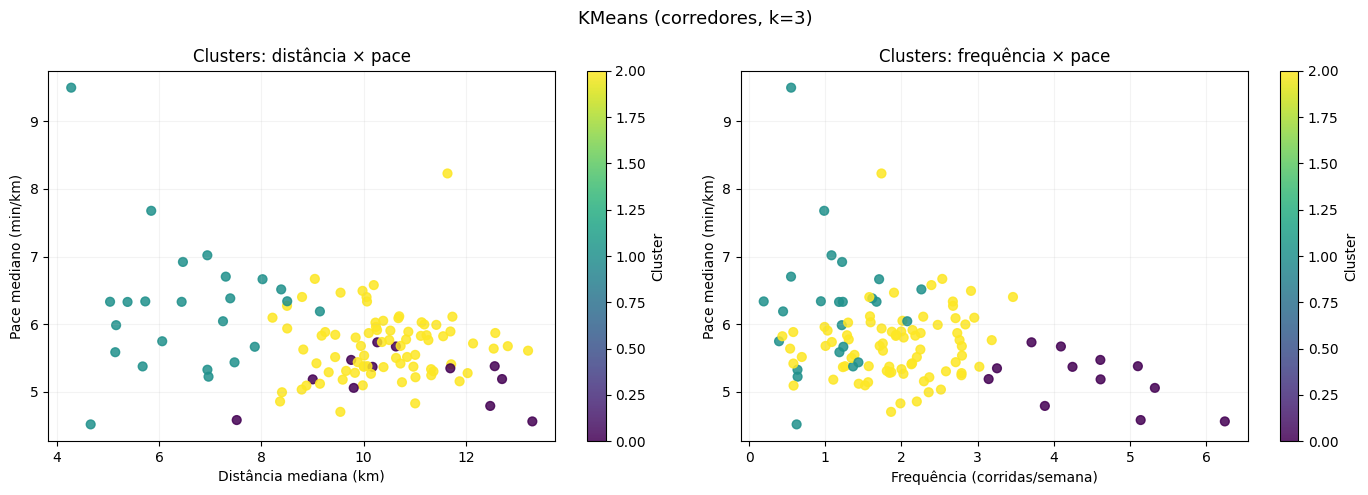

athlete,distance (m),pace_min_km,n_corridas,gender,frequencia_semana,cluster_corredor
i64,f64,f64,u32,str,f64,i32
20032449,13217.3,5.608225,264,"""F""",1.758325,2
15355766,9985.1,5.095992,207,"""M""",1.523659,2
19741163,11015.0,5.215572,423,"""M""",2.366906,2
28252317,5847.2,7.675505,96,"""F""",0.986784,1
8684584,9249.7,5.88365,139,"""M""",0.580549,2
…,…,…,…,…,…,…
15002603,6442.1,6.330183,235,"""F""",1.231287,1
22891135,10145.0,5.266638,267,"""M""",2.027115,2
10814597,10011.5,5.53541,260,"""M""",2.795699,2


In [3]:
resultado = treina_kmeans(df, n_clusters=3, plotar=True, verbose=True)
perfil = resultado.df_exibir
perfil

## Métricas e centros

In [4]:
print("Métricas:", resultado.metricas)
print("\nContagem por cluster:")
display(
    pl.DataFrame(resultado.detalhes["contagem_clusters"])
)

centros = []
for nome, centro in resultado.detalhes["centros"].items():
    centros.append({
        "cluster": nome,
        "distancia_km": round(centro[COL_DISTANCE] / 1000, 2),
        "pace_min_km": round(centro[COL_PACE], 2),
        "freq_semana": round(centro[COL_FREQUENCIA], 2),
    })

print("\nCentros dos clusters:")
pl.DataFrame(centros)

Métricas: {'inercia': 176.4359215775742, 'silhouette': 0.3621226428858316}

Contagem por cluster:


cluster_corredor,atletas
i64,i64
0,12
1,24
2,78



Centros dos clusters:


cluster,distancia_km,pace_min_km,freq_semana
str,f64,f64,f64
"""cluster_0""",10.83,5.19,4.45
"""cluster_1""",6.59,6.26,1.1
"""cluster_2""",10.39,5.69,1.94


## Perfil por cluster

In [5]:
resumo_cluster = (
    perfil.group_by(COL_CLUSTER_CORREDOR)
    .agg(
        pl.len().alias("atletas"),
        (pl.col(COL_DISTANCE) / 1000).median().alias("dist_km_med"),
        pl.col(COL_PACE).median().alias("pace_med"),
        pl.col(COL_FREQUENCIA).median().alias("freq_med"),
        (pl.col(COL_GENDER).str.to_uppercase() == "M").mean().alias("pct_masculino"),
    )
    .sort(COL_CLUSTER_CORREDOR)
)
resumo_cluster

cluster_corredor,atletas,dist_km_med,pace_med,freq_med,pct_masculino
i32,u32,f64,f64,f64,f64
0,12,10.449775,5.268496,4.429331,0.916667
1,24,6.705925,6.329394,1.184129,0.541667
2,78,10.3114,5.678868,1.958664,0.769231


## Boxplots por cluster

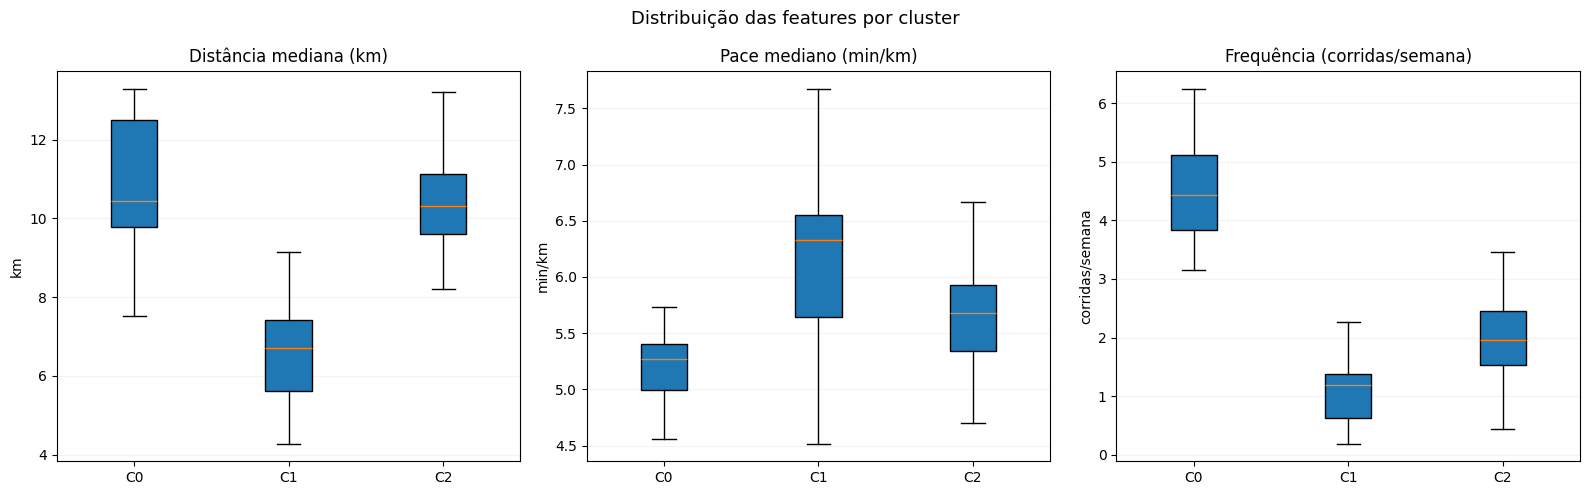

In [6]:
clusters = sorted(perfil[COL_CLUSTER_CORREDOR].unique().to_list())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dados_dist = [
    (perfil.filter(pl.col(COL_CLUSTER_CORREDOR) == c)[COL_DISTANCE] / 1000).to_numpy()
    for c in clusters
]
dados_pace = [
    perfil.filter(pl.col(COL_CLUSTER_CORREDOR) == c)[COL_PACE].to_numpy()
    for c in clusters
]
dados_freq = [
    perfil.filter(pl.col(COL_CLUSTER_CORREDOR) == c)[COL_FREQUENCIA].to_numpy()
    for c in clusters
]

labels = [f"C{c}" for c in clusters]

axes[0].boxplot(dados_dist, tick_labels=labels, patch_artist=True, showfliers=False)
axes[0].set_title("Distância mediana (km)")
axes[0].set_ylabel("km")
axes[0].grid(axis="y", alpha=0.15)

axes[1].boxplot(dados_pace, tick_labels=labels, patch_artist=True, showfliers=False)
axes[1].set_title("Pace mediano (min/km)")
axes[1].set_ylabel("min/km")
axes[1].grid(axis="y", alpha=0.15)

axes[2].boxplot(dados_freq, tick_labels=labels, patch_artist=True, showfliers=False)
axes[2].set_title("Frequência (corridas/semana)")
axes[2].set_ylabel("corridas/semana")
axes[2].grid(axis="y", alpha=0.15)

fig.suptitle("Distribuição das features por cluster", fontsize=13)
plt.tight_layout()
plt.show()

## Contagem de atletas por cluster

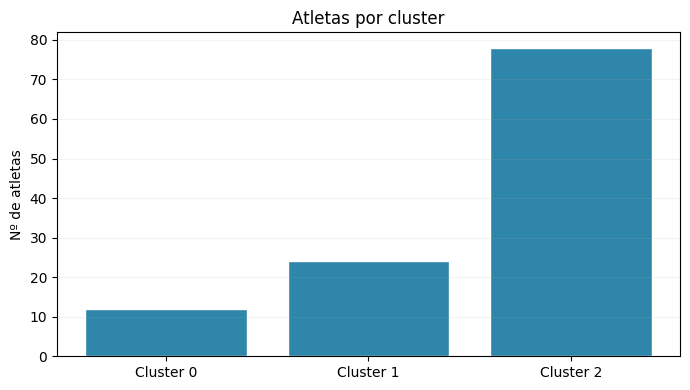

cluster_corredor,atletas
i32,u32
0,12
1,24
2,78


In [7]:
contagem = (
    perfil.group_by(COL_CLUSTER_CORREDOR)
    .agg(pl.len().alias("atletas"))
    .sort(COL_CLUSTER_CORREDOR)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [f"Cluster {c}" for c in contagem[COL_CLUSTER_CORREDOR].to_list()],
    contagem["atletas"].to_list(),
    color="#2E86AB",
    edgecolor="white",
)
ax.set_ylabel("Nº de atletas")
ax.set_title("Atletas por cluster")
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.show()

contagem

## Amostra de atletas por cluster

In [8]:
(
    perfil.select(
        COL_ATHLETE,
        COL_GENDER,
        COL_CLUSTER_CORREDOR,
        (pl.col(COL_DISTANCE) / 1000).round(2).alias("dist_km"),
        pl.col(COL_PACE).round(2).alias("pace"),
        pl.col(COL_FREQUENCIA).round(2).alias("freq_semana"),
    )
    .sort(COL_CLUSTER_CORREDOR, "pace")
)

athlete,gender,cluster_corredor,dist_km,pace,freq_semana
i64,str,i32,f64,f64,f64
13435425,"""M""",0,13.3,4.56,6.25
27655563,"""M""",0,7.52,4.58,5.14
7947798,"""M""",0,12.48,4.79,3.88
31787106,"""M""",0,9.81,5.06,5.33
19023831,"""M""",0,9.01,5.18,4.62
…,…,…,…,…,…
11284478,"""M""",2,9.55,6.47,1.9
14474051,"""F""",2,9.98,6.49,2.91
26583329,"""M""",2,10.2,6.58,2.39


## Testar outros valores de k (opcional)

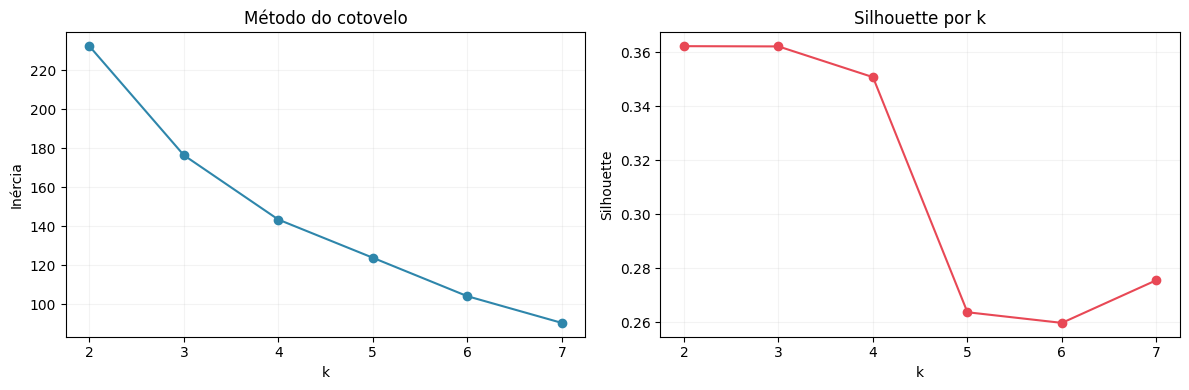

k,inercia,silhouette
i64,f64,f64
2,232.299224,0.362214
3,176.435922,0.362123
4,143.470546,0.35075
5,123.913858,0.263754
6,104.228164,0.259819
7,90.544604,0.275617


In [9]:
ks = range(2, 8)
silhouettes = []
inercias = []

for k in ks:
    r = treina_kmeans(df, n_clusters=k, plotar=False, verbose=False)
    silhouettes.append(r.metricas["silhouette"])
    inercias.append(r.metricas["inercia"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(ks), inercias, marker="o", color="#2E86AB")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do cotovelo")
axes[0].grid(alpha=0.15)

axes[1].plot(list(ks), silhouettes, marker="o", color="#E84855")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette por k")
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.show()

pl.DataFrame({"k": list(ks), "inercia": inercias, "silhouette": silhouettes})

## Perfil por regras (pace, volume, distância)

Além do KMeans, categorizamos atletas com regras interpretáveis:
- **nivel_pace**: rápido / intermediário / recreativo (tercis)
- **nivel_volume**: baixo / moderado / alto (corridas/semana)
- **nivel_distancia**: curta / média / longa
- **perfil_atleta**: avançado / fondista / iniciante / intermediário

In [10]:
perfil_regras = definir_perfil_atleta(df, verbose=True)
perfil_regras.head(10)

Atletas categorizados: 111 (mín. 20 corridas)

Por perfil:
shape: (4, 2)
┌───────────────┬─────────┐
│ perfil_atleta ┆ atletas │
│ ---           ┆ ---     │
│ str           ┆ u32     │
╞═══════════════╪═════════╡
│ intermediario ┆ 88      │
│ avancado      ┆ 10      │
│ iniciante     ┆ 7       │
│ fundista      ┆ 6       │
└───────────────┴─────────┘

Por nível de pace:
shape: (3, 2)
┌───────────────┬─────────┐
│ nivel_pace    ┆ atletas │
│ ---           ┆ ---     │
│ str           ┆ u32     │
╞═══════════════╪═════════╡
│ intermediario ┆ 37      │
│ recreativo    ┆ 37      │
│ rapido        ┆ 37      │
└───────────────┴─────────┘

Por volume:
shape: (3, 2)
┌──────────────┬─────────┐
│ nivel_volume ┆ atletas │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ moderado     ┆ 61      │
│ baixo        ┆ 35      │
│ alto         ┆ 15      │
└──────────────┴─────────┘

Por distância:
shape: (3, 2)
┌─────────────────┬─────────┐
│ nivel_distancia ┆ atletas │
│

athlete,distance (m),pace_min_km,n_corridas,gender,frequencia_semana,nivel_pace,nivel_volume,nivel_distancia,perfil_atleta
i64,f64,f64,u32,str,f64,str,str,str,str
13435425,13300.65,4.563065,1210,"""M""",6.246313,"""rapido""","""alto""","""longa""","""avancado"""
27655563,7519.15,4.583095,592,"""M""",5.141439,"""rapido""","""alto""","""curta""","""avancado"""
7947798,12477.35,4.791752,982,"""M""",3.883616,"""rapido""","""alto""","""longa""","""avancado"""
31787106,9807.6,5.057686,137,"""M""",5.327778,"""rapido""","""alto""","""media""","""avancado"""
19023831,9005.8,5.184377,747,"""M""",4.615181,"""rapido""","""alto""","""media""","""avancado"""
12902518,12708.65,5.188902,364,"""M""",3.145679,"""rapido""","""alto""","""longa""","""avancado"""
5151970,11696.9,5.348089,1183,"""M""",3.25511,"""rapido""","""alto""","""media""","""avancado"""
20653961,10175.85,5.369251,620,"""M""",4.246575,"""rapido""","""alto""","""media""","""avancado"""
45799771,10003.4,5.371125,73,"""M""",3.023669,"""rapido""","""alto""","""media""","""avancado"""


## Contagem e cruzamento com KMeans

Cruzamento perfil × cluster:


perfil_atleta,cluster_corredor,n
str,i32,u32
"""avancado""",0,9
"""avancado""",2,1
"""fundista""",2,6
"""iniciante""",1,7
"""intermediario""",0,3
"""intermediario""",1,14
"""intermediario""",2,71


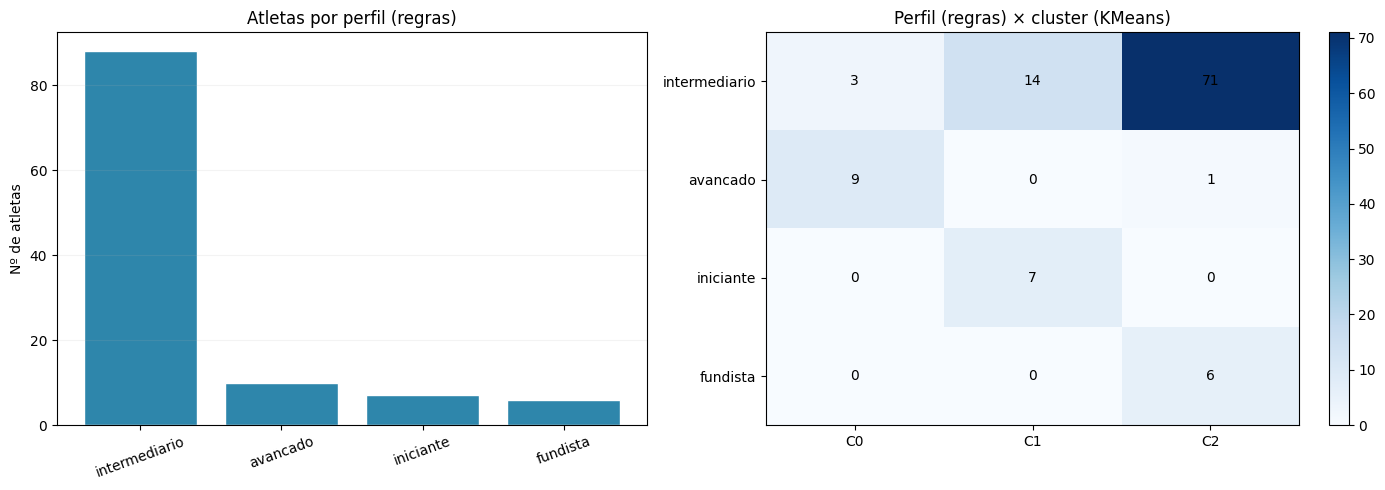

athlete,gender,perfil_atleta,nivel_pace,nivel_volume,nivel_distancia,dist_km,pace,freq_semana
i64,str,str,str,str,str,f64,f64,f64
13435425,"""M""","""avancado""","""rapido""","""alto""","""longa""",13.3,4.56,6.25
27655563,"""M""","""avancado""","""rapido""","""alto""","""curta""",7.52,4.58,5.14
7947798,"""M""","""avancado""","""rapido""","""alto""","""longa""",12.48,4.79,3.88
31787106,"""M""","""avancado""","""rapido""","""alto""","""media""",9.81,5.06,5.33
19023831,"""M""","""avancado""","""rapido""","""alto""","""media""",9.01,5.18,4.62
…,…,…,…,…,…,…,…,…
23729907,"""M""","""intermediario""","""recreativo""","""moderado""","""media""",8.39,6.51,2.26
26583329,"""M""","""intermediario""","""recreativo""","""moderado""","""media""",10.2,6.58,2.39
27950722,"""F""","""intermediario""","""recreativo""","""moderado""","""media""",8.02,6.66,1.71


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cont_perfil = (
    perfil_regras.group_by(COL_PERFIL_ATLETA)
    .agg(pl.len().alias("atletas"))
    .sort("atletas", descending=True)
)
axes[0].bar(
    cont_perfil[COL_PERFIL_ATLETA].to_list(),
    cont_perfil["atletas"].to_list(),
    color="#2E86AB",
    edgecolor="white",
)
axes[0].set_title("Atletas por perfil (regras)")
axes[0].set_ylabel("Nº de atletas")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.15)

# Cruzamento regras × cluster KMeans
cruzado = (
    perfil_regras.select(COL_ATHLETE, COL_PERFIL_ATLETA)
    .join(
        resultado.df_exibir.select(COL_ATHLETE, COL_CLUSTER_CORREDOR),
        on=COL_ATHLETE,
        how="inner",
    )
)
matriz = (
    cruzado.group_by(COL_PERFIL_ATLETA, COL_CLUSTER_CORREDOR)
    .agg(pl.len().alias("n"))
    .sort(COL_PERFIL_ATLETA, COL_CLUSTER_CORREDOR)
)
print("Cruzamento perfil × cluster:")
display(matriz)

perfis = cont_perfil[COL_PERFIL_ATLETA].to_list()
clusters_ids = sorted(cruzado[COL_CLUSTER_CORREDOR].unique().to_list())
heat = []
for p in perfis:
    row = []
    for c in clusters_ids:
        hit = matriz.filter(
            (pl.col(COL_PERFIL_ATLETA) == p) & (pl.col(COL_CLUSTER_CORREDOR) == c)
        )
        row.append(hit["n"][0] if hit.height else 0)
    heat.append(row)

im = axes[1].imshow(heat, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(clusters_ids)), [f"C{c}" for c in clusters_ids])
axes[1].set_yticks(range(len(perfis)), perfis)
axes[1].set_title("Perfil (regras) × cluster (KMeans)")
for i, row in enumerate(heat):
    for j, val in enumerate(row):
        axes[1].text(j, i, str(val), ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

(
    perfil_regras.select(
        COL_ATHLETE,
        COL_GENDER,
        COL_PERFIL_ATLETA,
        COL_NIVEL_PACE,
        COL_NIVEL_VOLUME,
        COL_NIVEL_DISTANCIA,
        (pl.col(COL_DISTANCE) / 1000).round(2).alias("dist_km"),
        pl.col(COL_PACE).round(2).alias("pace"),
        pl.col(COL_FREQUENCIA).round(2).alias("freq_semana"),
    )
    .sort(COL_PERFIL_ATLETA, "pace")
)

## Fichas visuais dos atletas

Cada ficha mostra: ID, nome fictício, gênero, quantidade de corridas, cluster do KMeans, perfil por regras e a posição do pace em relação ao **melhor** e ao **pior** da mesma categoria.


In [12]:
fichas = montar_fichas_atletas(perfil_regras, resultado.df_exibir)

print(f"Fichas montadas: {fichas.height} atletas")
tabela_fichas(fichas)


Fichas montadas: 111 atletas


id,nome,genero,corridas,kmeans,perfil,pace,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,u32,i32,str,f64,f64,f64,u32,u32
13435425,"""Gilberto Pacheco""","""M""",1210,0,"""avancado""",4.56,0.0,0.816,1,10
27655563,"""Patrick Neves""","""M""",592,0,"""avancado""",4.58,0.02,0.796,2,10
7947798,"""Vitor Antunes""","""M""",982,0,"""avancado""",4.79,0.229,0.587,3,10
31787106,"""Jonas Farias""","""M""",137,0,"""avancado""",5.06,0.495,0.321,4,10
19023831,"""Ciro Albuquerque""","""M""",747,0,"""avancado""",5.18,0.621,0.195,5,10
…,…,…,…,…,…,…,…,…,…,…
23729907,"""Thiago Rocha""","""M""",841,1,"""intermediario""",6.51,1.995,1.713,84,88
26583329,"""Felipe Souza""","""M""",249,2,"""intermediario""",6.58,2.058,1.65,85,88
27950722,"""Laura Mendes""","""F""",192,1,"""intermediario""",6.66,2.145,1.563,86,88


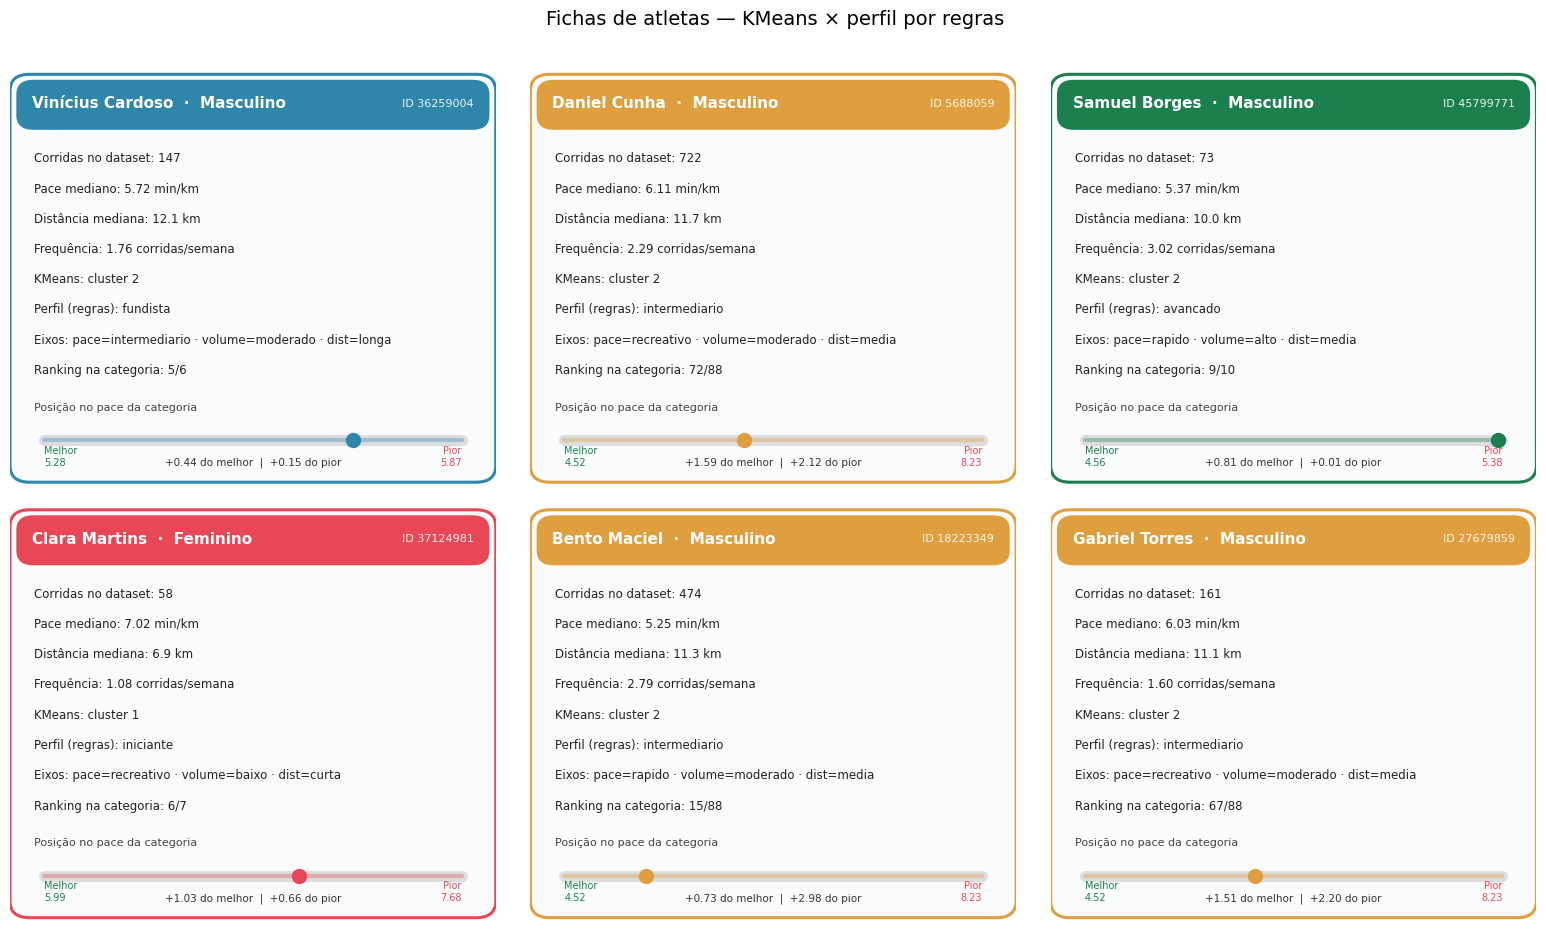

In [13]:
# Amostra estratificada: 1 atleta de cada perfil (+ extras até 6)
fig = plotar_fichas_atletas(fichas, n=6, seed=42)
plt.show()


### Ficha individual

Troque o `athlete_id` para inspecionar um corredor específico.


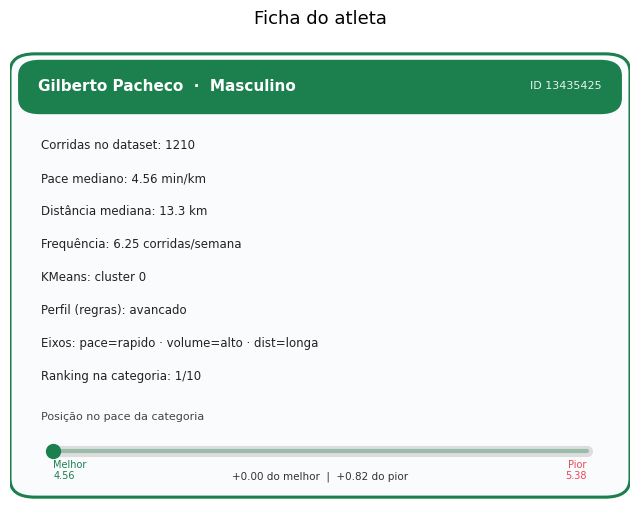

Atleta 13435425 — Gilberto Pacheco
  Gênero: M
  Corridas: 1210
  KMeans: cluster 0
  Perfil: avancado
  Pace 4.56 min/km | +0.00 do melhor | +0.82 do pior (categoria avancado)
  Ranking: 1/10 na categoria


In [14]:
# Exemplo: primeiro atleta da tabela de fichas
athlete_id = fichas[COL_ATHLETE][0]

fig = plotar_ficha_atleta(fichas, athlete_id=athlete_id)
plt.show()

# Detalhe textual
linha = fichas.filter(pl.col(COL_ATHLETE) == athlete_id).row(0, named=True)
print(f"Atleta {linha[COL_ATHLETE]} — {linha['nome_ficticio']}")
print(f"  Gênero: {linha[COL_GENDER]}")
print(f"  Corridas: {linha['n_corridas']}")
print(f"  KMeans: cluster {linha[COL_CLUSTER_CORREDOR]}")
print(f"  Perfil: {linha[COL_PERFIL_ATLETA]}")
print(
    f"  Pace {linha[COL_PACE]:.2f} min/km | "
    f"+{linha['dist_pace_melhor']:.2f} do melhor | "
    f"+{linha['dist_pace_pior']:.2f} do pior "
    f"(categoria {linha[COL_PERFIL_ATLETA]})"
)
print(
    f"  Ranking: {linha['ranking_na_categoria']}/"
    f"{linha['atletas_na_categoria']} na categoria"
)
